In [36]:
from utils import Helper
from pathlib import Path
import re, os
import fitz
utils = Helper()
import pandas as pd
path = "language.json"

data = utils.load_json(path)
#data.keys()

In [ ]:
text = """ 
 }ìÐðĊĴÐīÐĮĴī­ĴÐĮœ­ĨĮ­īÐÐĊĴÐīÐÌĴďìÐÌæÐðĊĴÐīÐĮĴĨ­řĉÐĊĴĮåīďĉŦď­ĴðĊæĴďťŘÐÌďĊÅďīīďœðĊæĮȘ}ìÐÅķĊāÐīĮœ­ĨĮ­īÐÐĊĴÐīÐÌĴďìÐÌæÐ
ĴìÐÅķĊāÐīĨīðÆÐīðĮāȘ9­ðīŒ­ăķÐæ­ðĊĮȥȧăďĮĮÐĮȨďĊĴìÐðĊĴÐīÐĮĴī­ĴÐĮœ­ĨÆďĊĴī­ÆĴĮ­ĊÌÅķĊāÐīĮœ­ĨÆďĊĴī­ÆĴĮīÐÆďæĊðĮÐÌðĊ­Įì9ăďœ>ÐÌæðĊæ
tÐĮÐīŒÐ­īÐĴī­ĊĮåÐīīÐÌĴďĴìÐwĴ­ĴÐĉÐĊĴďåqīďťĴ­ĊÌOďĮĮ­ĮĨ­īĴďåðĊĴÐīÐĮĴÐŘĨÐĊĮÐ­ĊÌåķÐăďðă­ĊÌœ­ĴÐīÐŘĨÐĊĮÐďĊĮÐĴĴăÐĉÐĊĴȘ}ìÐå­ðī
Œ­ăķÐďĊīÐĨďīĴðĊæÌ­ĴÐðĮīÐĨďīĴÐÌķĊÌÐīȵZĴìÐī9ðĊ­ĊÆð­ăĮĮÐĴĮȶ­ĊÌȵZĴìÐī9ðĊ­ĊÆð­ăOð­ÅðăðĴðÐĮȶȘ
 }ìÐìÐÌæðĊæăďĮĮīÐÆďæĊðĮÐÌðĊďĴìÐīÆďĉĨīÐìÐĊĮðŒÐðĊÆďĉÐÌķīðĊæĴìÐřÐ­īðĮ`ǠȘǟǤÆīďīÐĮȧqīÐŒðďķĮÐ­īȚæ­ðĊďå`ǠǥȘǠǨÆīďīÐĮȨ­ĊÌæ­ðĊďå
`ɁǡǠȘǣǨÆīďīÐĮȧqīÐŒðďķĮÐ­īȚæ­ðĊďå`ǠǡȘǠǟÆīďīÐĮȨì­ĮÅÐÐĊīÐÆă­ĮĮðťÐÌĴďwĴ­ĴÐĉÐĊĴďåqīďťĴ­ĊÌOďĮĮȘ
 #ķīðĊæĴìÐÆķīīÐĊĴřÐ­īșĴìÐďĉĨ­Ċřì­ĮÆ­ĊÆÐăăÐÌĴìÐðĊĴÐīÐĮĴī­ĴÐĮœ­ĨĮďĊ­ÆÆďķĊĴďåĨīÐĨ­řĉÐĊĴďåķĊÌÐīăřðĊæåďīÐðæĊÆķīīÐĊÆřÅďīīďœðĊæĮ
­ĊÌ ĴìÐ ÆďīīÐĮĨďĊÌðĊæÅ­ă­ĊÆÐðĊìÐÌæðĊæ īÐĮÐīŒÐĨÐīĴ­ðĊðĊæ ĴďðĊĴÐīÐĮĴ ī­ĴÐĮœ­ĨĮì­ĮÅÐÐĊ īÐÆřÆăÐÌ ĴďwĴ­ĴÐĉÐĊĴďåqīďťĴ ­ĊÌOďĮĮȘ}ìÐ
ðĉĨ­ÆĴďåĴìÐ­åďīÐĉÐĊĴðďĊÐÌīÐĮķăĴÐÌðĊæ­ðĊďå`ǠǤȘǟǦÆīďīÐĮșœìðÆìì­ĮÅÐÐĊīÐÆďæĊðĮÐÌðĊɁȵZĴìÐīɁ'ŘĨÐĊĮÐĮȶȘ
"""
import re
re.findall(r"\b\d+(?:[\.,]\d+)*\b", text)

In [37]:
# text = data["gibber"]
# txt = re.findall(r"[A-Za-z]", text)
# non_txt = re.findall(r"\S", text)

# ratio = len(txt) / len(non_txt)
def english_word_ratio(text):
    # Normalize whitespace
    text = re.sub(r"\b\d+(?:[\.,]\d+)*\b"," ",text).strip()
    text = re.sub(r"[()\[\]{}\-_,.;:*/\\|+~`'\"@#$%^&=<>!?\n\t]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Split into tokens
    tokens = text.split(" ")

    # Count English-like tokens (words or numbers)
    english_like = [t for t in tokens if re.fullmatch(r"\b[A-Za-z]+,?\b", t)]
    # print(len(english_like))
    # print(len(tokens))
    ratio = len(english_like) / max(len(tokens), 1)

    return ratio

In [ ]:
all_data = []

folder_pdf = r"C:\Users\kaustubh.keny\Projects\INPUTS\ANNUAL_REPORTS\ANNUAL_REPORTS_2025"
for idx, file in enumerate(os.listdir(folder_pdf)):

    file_path = os.path.join(folder_pdf, file)

    stem = Path(file_path).name
    print(f"COUNT: {stem}")

    doc = fitz.open(file_path)

    page_count = doc.page_count
    for page_num in range(0, page_count-1):
        page = doc[page_num]
        text = page.get_text("text")
        ratio = english_word_ratio(text)
        all_data.append([stem,page_num, ratio])


In [34]:
final_df = pd.DataFrame(all_data, columns = ['pdf','page','ratio'])
final_df.to_csv("2025_ENGLISH.csv",index=False)

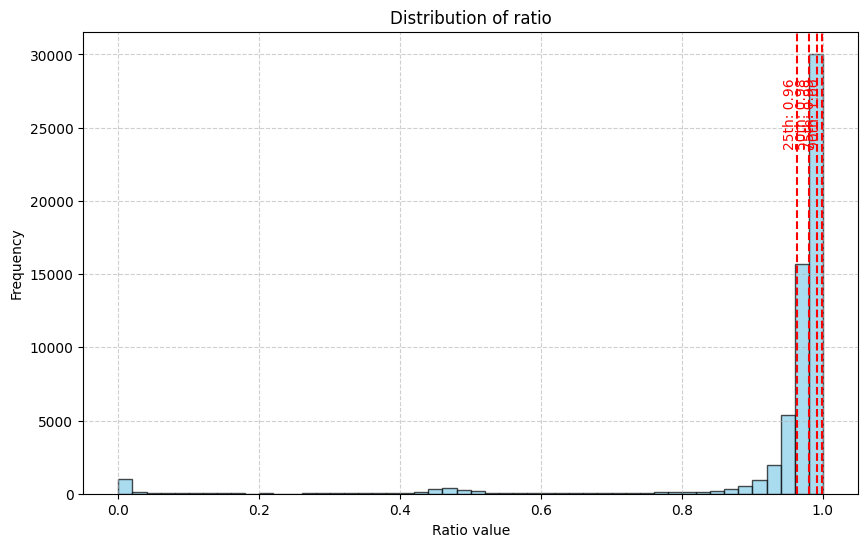

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ratio_distribution(df, column="ratio", percentiles=[25,50,75,90]):
    plt.figure(figsize=(10,6))
    plt.hist(df[column], bins=50, color="skyblue", edgecolor="black", alpha=0.7)
    plt.title(f"Distribution of {column}")
    plt.xlabel("Ratio value")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.5)

    # Compute percentile values
    values = np.percentile(df[column].dropna(), percentiles)

    for p, val in zip(percentiles, values):
        plt.axvline(val, color="red", linestyle="--", linewidth=1.5)
        plt.text(val, plt.ylim()[1]*0.9, f"{p}th: {val:.2f}",
                 rotation=90, color="red", va="top", ha="right")

    plt.show()

# Example usage
plot_ratio_distribution(final_df, "ratio")


In [25]:
path = r"C:\Users\kaustubh.keny\Projects\INPUTS\ANNUAL_REPORTS\ANNUAL_REPORTS_2025\2025_IDBI.pdf"
doc = fitz.open(path)

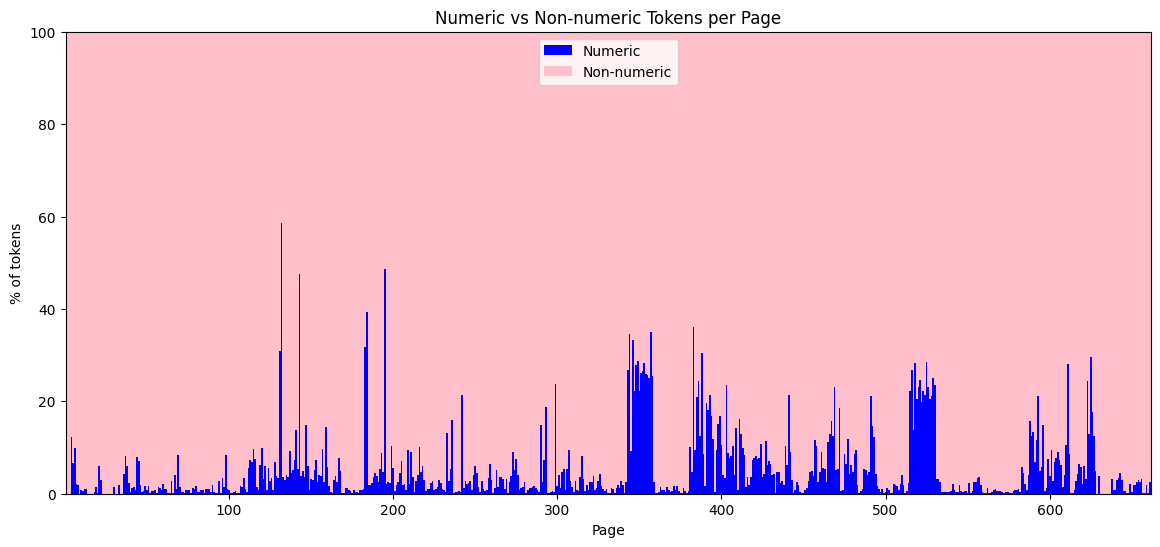

In [26]:
import re
import matplotlib.pyplot as plt
import pandas as pd

word_pattern = r"[A-Za-z]+"
num_pattern  = r"\d+(?:[\.,]\d+)*"

def page_token_counts(text):
    tokens = text.split()
    words = sum(1 for t in tokens if re.fullmatch(word_pattern, t))
    nums  = sum(1 for t in tokens if re.fullmatch(num_pattern, t))
    total = len(tokens)
    return words, nums, total

# Collect per-page data
all_data = []
for page_num in range(doc.page_count):
    text = doc[page_num].get_text("text")
    words, nums, total = page_token_counts(text)
    if total > 0:
        alpha_ratio = (words / total) * 100
        num_ratio   = (nums / total) * 100
    else:
        alpha_ratio = num_ratio = 0
    all_data.append([page_num+1, alpha_ratio, num_ratio])

df = pd.DataFrame(all_data, columns=["page","alpha_ratio","num_ratio"])

df["other_ratio"] = 100 - df["num_ratio"]

plt.figure(figsize=(14,6))
plt.bar(
    df["page"],
    df["num_ratio"],
    width=1.0,          # bars touch each other
    color="blue",
    label="Numeric"
)
plt.bar(
    df["page"],
    df["other_ratio"],
    bottom=df["num_ratio"],
    width=1.0,
    color="pink",
    label="Non-numeric"
)

plt.xlabel("Page")
plt.ylabel("% of tokens")
plt.title("Numeric vs Non-numeric Tokens per Page")
plt.ylim(0,100)
plt.xlim(0.5, len(df)+0.5)
plt.legend()
plt.show()

